In [1]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

print("Qiskit Version:", qiskit.__version__)
simulator = AerSimulator()
print(simulator)

Qiskit Version: 2.5.1
AerSimulator('aer_simulator')


Shots | Count(0) | Count(1) | P(0)    | P(1)
----------------------------------------------------
  100 |       51 |       49 | 0.5100 | 0.4900
 1000 |      486 |      514 | 0.4860 | 0.5140
10000 |     5005 |     4995 | 0.5005 | 0.4995


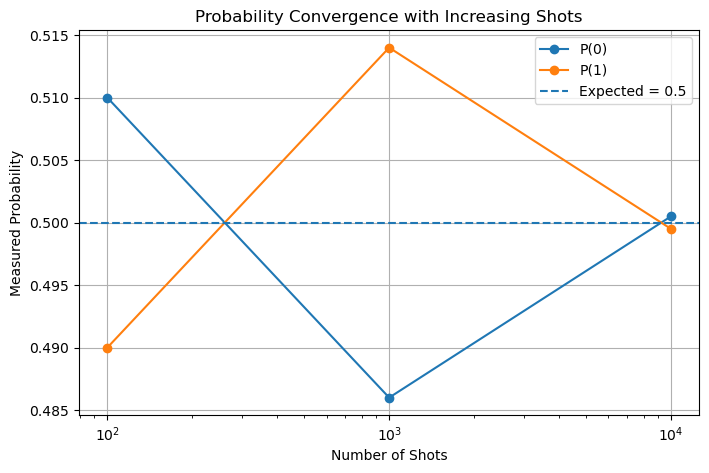

In [2]:
shot_values = [100, 1000, 10000]
results_table = []

for shots in shot_values:
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.measure(0, 0)

    counts = simulator.run(qc, shots=shots).result().get_counts()
    p0 = counts.get("0", 0) / shots
    p1 = counts.get("1", 0) / shots
    results_table.append((shots, counts.get("0", 0), counts.get("1", 0), p0, p1))

print("Shots | Count(0) | Count(1) | P(0)    | P(1)")
print("-" * 52)
for row in results_table:
    print(f"{row[0]:5} | {row[1]:8} | {row[2]:8} | {row[3]:.4f} | {row[4]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot([r[0] for r in results_table], [r[3] for r in results_table], marker="o", label="P(0)")
plt.plot([r[0] for r in results_table], [r[4] for r in results_table], marker="o", label="P(1)")
plt.axhline(0.5, linestyle="--", label="Expected = 0.5")
plt.xscale("log")
plt.xlabel("Number of Shots")
plt.ylabel("Measured Probability")
plt.title("Probability Convergence with Increasing Shots")
plt.legend()
plt.grid()
plt.show()
